# Project - Traffic Sign Images


## 개요
  - 다양한 도로 표지판 이미지가 있습니다. (43가지)
  - 도로 표지판 이미지를 구분해내는 모델을 만들어 봅시다.

## 목표
  - validation dataset 에 대해 99% 이상의 정확도를 가지는 모델을 만들면 정답입니다.
  - 전처리, 모델 정의, 학습 등 구현 방법에 정답은 없습니다.
    - (참고로, 딥러닝 모델을 사용하지 않아도 구현이 가능합니다.)
  - 아래 코드 틀은 배운 방법을 이용한 가장 쉬운 방법의 가이드라인일 뿐, 지키지 않아도 됩니다.
  - 학습 시간을 단축시키고 싶다면, colab 을 사용하셔도 좋습니다.

## 힌트
  - 전처리와 간단한 CNN 기반 모델 학습으로 충분히 해결이 가능합니다.
    - 코드 틀은 이 방법을 첫째 방안으로 고려하여 작성되었습니다.
  - 그 외 아래와 같은 방법이 쉬운 해결책이 될 수 있고, 목표를 달성하면 정답으로 인정됩니다.
    - transfer learning 을 이용해서도 해결이 가능합니다.
    - 인터넷 상 존재하는 다른 모델을 가져와도 해결이 가능합니다.
  - 본 과정의 수료 평가를 위해, 뉴럴네트워크 기반 모델이 아닌 다른 방법은 정답으로 인정하지 않습니다.
  - 목표에 도달하지 못하더라도, Preprocessing, Data Augmentation, Model Define, Model Compile 과정 등을 잘 작성하시면, 부분점수가 부여됩니다. 



In [1]:
import urllib
import zipfile

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
def download_and_extract_data():
    url = 'https://fastcampusjhpark.s3.ap-northeast-2.amazonaws.com/project_sign.zip'
    urllib.request.urlretrieve(url, 'germantrafficsigns.zip')
    with zipfile.ZipFile('germantrafficsigns.zip', 'r') as zip_ref:
        zip_ref.extractall()

download_and_extract_data()

# 1 & 2. 데이터 준비 & 이미지 전처리

  - 다운로드 받은 데이터를 읽어서 준비합니다.
  - 전처리를 수행합니다.

In [3]:
IMG_SIZE = 30
BATCH_SIZE = 32

# This code has changed. Now instead of the ImageGenerator just rescaling
train_datagen = ImageDataGenerator(
      rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        'train/', 
    target_size= (IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
        class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
        'valid/',
    target_size= (IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
        class_mode='categorical')

Found 27439 images belonging to 43 classes.
Found 5872 images belonging to 43 classes.


# 3. 모델 정의

  - 모델 모양을 정의합니다.
  - Input, Output 모양을 유의하세요.

In [13]:
# model = tf.keras.models.Sequential([
#     # model을 정의하세요 
#     tf.keras.layers.Dense(43, activation='softmax') 
# ])


def create_model():
    model = tf.keras.models.Sequential([
        # 1
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),
        
        # 2
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),
        
        # 3
        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Dropout(0.25),
        
        # Dense
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(43, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


model = create_model()


# history = model.fit(train_generator,
#                     epochs=10,
#                     verbose=1,
#                     validation_data=validation_generator,
#                     batch_size=BATCH_SIZE)

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.3727 - loss: 2.5877 - val_accuracy: 0.9068 - val_loss: 0.3243
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.8488 - loss: 0.4772 - val_accuracy: 0.9644 - val_loss: 0.1183
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9046 - loss: 0.2957 - val_accuracy: 0.9700 - val_loss: 0.1094
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9321 - loss: 0.2065 - val_accuracy: 0.9687 - val_loss: 0.0915
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9372 - loss: 0.1961 - val_accuracy: 0.9780 - val_loss: 0.0732
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9491 - loss: 0.1612 - val_accuracy: 0.9828 - val_loss: 0.0553
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9527 - loss: 0.1467 - val_accuracy: 0.9867 - val_loss: 0.0399
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9586 - loss: 0.1328 - 

# 4. 모델 컴파일

  - 학습 방법을 정의하세요
  - loss, optimizer, metrics 를 올바르게 지정하면 충분합니다.

In [ ]:
# model.compile(
#   # 학습 방법을 의하세요 
#   loss='categorical_crossentropy'
# )

# 5. 모델 학습

  - 학습을 위한 epoch, batch_size 등을 설정하세요.
  - 이 외에 사용하고 싶은 기법들은 자유롭게 도입하셔도 됩니다.

In [ ]:
# model.fit(
#         train_generator,
#         validation_data=validation_generator,
#         epochs= # epoch 도 마음대로 설정하세요
#         batch_size=BATCH_SIZE
# )

history = model.fit(train_generator,
                    epochs=10,
                    verbose=1,
                    validation_data=validation_generator,
                    batch_size=BATCH_SIZE)

# 6. 모델 저장

- 학습된 모델을 저장합니다.
- 저장된 모델과 ipynb 파일을 같이 제출하세요, 모델을 이용하여 성능 평가 후 채점됩니다.

In [14]:
model.save("my_model.h5")

In [10]:
import tensorflow as tf

new_model = tf.keras.models.load_model('my_model.h5')


def preprocess(image, label):
    image = image/255
    return image, label

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory='valid/',
    label_mode='categorical',
    image_size= (IMG_SIZE,IMG_SIZE)
    , batch_size=BATCH_SIZE)
val_ds = val_ds.map(
        preprocess, num_parallel_calls=tf.data.experimental.AUTOTUNE)


#results = new_model.evaluate(val_ds, verbose=2)
#tf.print('Accuracy: ', results[1]*100)

Found 5872 files belonging to 43 classes.


# Appendix

- 이미지를 View 합니다.
- model 로 predict 를 합니다.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch of images and labels
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory='valid/',
    image_size= (IMG_SIZE,IMG_SIZE)
    , batch_size=BATCH_SIZE)

Found 5872 files belonging to 43 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


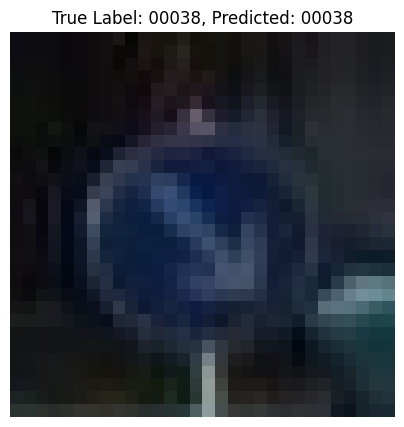

In [12]:
images, labels = next(iter(val_ds.shuffle(buffer_size=10000)))

data_index = 0

selected_image = images[data_index].numpy().astype("uint8")
selected_label = labels[data_index].numpy() #np.argmax(labels[data_index].numpy())

image_to_predict = np.expand_dims(selected_image/255, axis=0)

# Make a prediction
predictions = model.predict(image_to_predict)
predicted_label = np.argmax(predictions)

plt.figure(figsize=(5,5))
plt.imshow(selected_image)
class_names = val_ds.class_names
plt.title(f"True Label: {class_names[selected_label]}, Predicted: {class_names[predicted_label]}")
plt.axis("off")
plt.show()

# (선택) Transfer Learning

  - transfer learning 을 이용해서도 문제를 풀어볼 수 있습니다. (위 방법과 성능을 비교해보세요)

In [16]:

# model = tf.keras.models.Sequential([
#     # 1
#     tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(2,2),
#     tf.keras.layers.Dropout(0.25),
    
#     # 2
#     tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(2,2),
#     tf.keras.layers.Dropout(0.25),
    
#     # 3
#     tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.MaxPooling2D(2,2),
#     tf.keras.layers.Dropout(0.25),
    
#     # Dense
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.5),
#     tf.keras.layers.Dense(43, activation='softmax')
# ])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [17]:
history = model.fit(train_generator,
                    epochs=10,
                    verbose=1,
                    validation_data=validation_generator,
                    batch_size=BATCH_SIZE)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9837 - loss: 0.0463 - val_accuracy: 0.9951 - val_loss: 0.0181
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9949 - val_loss: 0.0180
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9851 - loss: 0.0474 - val_accuracy: 0.9954 - val_loss: 0.0147
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9853 - loss: 0.0451 - val_accuracy: 0.9911 - val_loss: 0.0273
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.9874 - loss: 0.0372 - val_accuracy: 0.9937 - val_loss: 0.0225
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9837 - loss: 0.0511 - val_accuracy: 0.9946 - val_loss: 0.0218
Epoch 7/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9863 - loss: 0.0423 - val_accuracy: 0.9957 - val_loss: 0.0137
Epoch 8/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9860 - loss: 0.0451 - 

In [18]:
model.save("my_model.h5")